In [1]:
import pandas as pd
df=pd.read_csv('/content/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.dropna(inplace=True)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
cat_cols=df.select_dtypes(include='object').columns

label_encoders={}
for col in cat_cols:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  label_encoders[col]=le
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
x=df.drop('target',axis=1)
y=df['target']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [11]:
from sklearn.svm import SVC
svm_linear=SVC(kernel='linear',C=1)
svm_linear.fit(x_train,y_train)
y_pred_linear=svm_linear.predict(x_test)


In [15]:
from sklearn.metrics import *
acc=accuracy_score(y_test,y_pred_linear)
print("Accuracy:",acc)

Accuracy: 0.8146341463414634


In [17]:
confusion_matrix(y_test,y_pred_linear)

array([[72, 30],
       [ 8, 95]])

In [18]:
# svm with polynomial kernel
svm_poly=SVC(kernel='poly',degree=3,C=1)
svm_poly.fit(x_train,y_train)
y_pred_poly=svm_poly.predict(x_test)

accuracy_score(y_test,y_pred_poly)

0.9073170731707317

In [19]:
confusion_matrix(y_test,y_pred_poly)

array([[ 85,  17],
       [  2, 101]])

In [21]:
# with rbf kernel
svm_rbf=SVC(kernel='rbf',C=1,gamma='scale')
svm_rbf.fit(x_train,y_train)
y_pred_rbf=svm_rbf.predict(x_test)

accuracy_score(y_test,y_pred_rbf)

0.8878048780487805

In [30]:
df=pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [31]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [41]:
cat_cols=df.select_dtypes(include='object').columns
cat_cols.value_counts()


,count
Loan_ID,1
Gender,1
Married,1
Dependents,1
Education,1
Self_Employed,1
Property_Area,1
Loan_Status,1


In [42]:
for col in cat_cols:
  df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipython-input-3030478535.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [43]:
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
  df[col].fillna(df[col].mean(),inplace=True)

/tmp/ipython-input-126753646.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)


In [44]:
df.isnull().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [55]:
x=df.drop(['Loan_Status', 'Loan_ID'],axis=1)
y=df['Loan_Status']

# Encode categorical features in x
from sklearn.preprocessing import LabelEncoder
cat_cols_x = x.select_dtypes(include='object').columns

label_encoders_x={}
for col in cat_cols_x:
  le=LabelEncoder()
  x[col]=le.fit_transform(x[col])
  label_encoders_x[col]=le

# Encode target variable y
le_y = LabelEncoder()
y = le_y.fit_transform(y)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
svm=SVC(kernel='poly',degree=3,C=1)
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)

accuracy_score(y_test,y_pred)

0.772972972972973

In [61]:
confusion_matrix(y_test,y_pred)

array([[ 28,  37],
       [  5, 115]])

In [56]:
# Train SVC with RBF kernel for Loan Status prediction
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_rbf_loan = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf_loan.fit(x_train, y_train)
y_pred_rbf_loan = svm_rbf_loan.predict(x_test)

accuracy_rbf_loan = accuracy_score(y_test, y_pred_rbf_loan)
print(f"Accuracy with RBF kernel on Loan Status dataset: {accuracy_rbf_loan}")

Accuracy with RBF kernel on Loan Status dataset: 0.7837837837837838


In [62]:
confusion_matrix(y_test,y_pred_rbf_loan)

array([[ 27,  38],
       [  2, 118]])

In [63]:
#with linear
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm_poly=SVC(kernel='linear',C=1)
svm_poly.fit(x_train,y_train)
y_pred_poly=svm_poly.predict(x_test)

accuracy_score(y_test,y_pred_poly)


0.7837837837837838

In [64]:
confusion_matrix(y_test,y_pred_poly)

array([[ 27,  38],
       [  2, 118]])

In [65]:
#plots for linear, poly and rbf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix



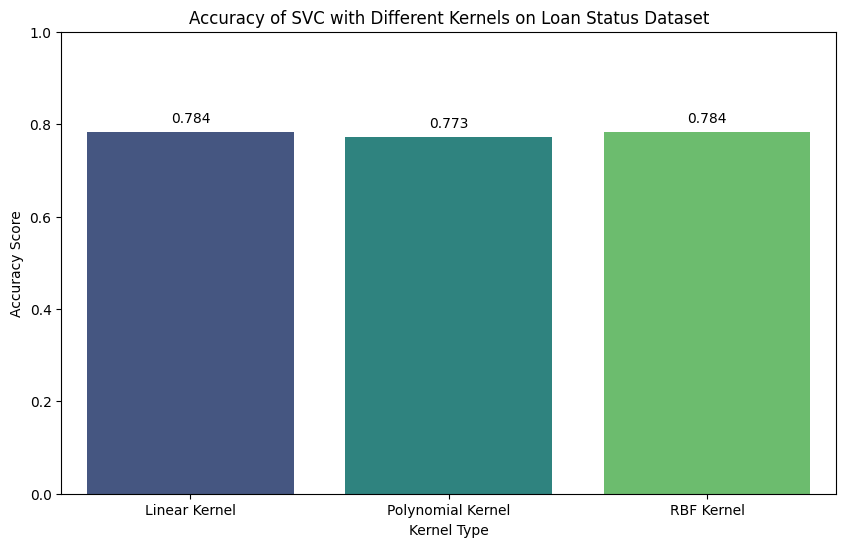

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracies = {
    'Linear Kernel': accuracy_linear_loan, # from the last run of zNcf8oRpQ_om
    'Polynomial Kernel': accuracy_poly_loan, # from the last run of 8wgvAfBXGXux
    'RBF Kernel': accuracy_rbf_loan # from the last run of 060c7597
}

kernels = list(accuracies.keys())
scores = list(accuracies.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=kernels, y=scores, hue=kernels, palette='viridis', legend=False)
plt.ylim(0, 1)
plt.title('Accuracy of SVC with Different Kernels on Loan Status Dataset')
plt.xlabel('Kernel Type')
plt.ylabel('Accuracy Score')

for index, value in enumerate(scores):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center')

plt.show()